# Introduction to Recurrent Neural Networks

## Our World in Sequence

Our world is fundamentally sequential. A movie is a series of 'shots' layered on top of each other, music is a series of notes, tomorrow's temperature is influenced by today's weather. Even the way you read sentences, ***'I went to the bank'***, there is context, if you were to read the words in isolation, they would make no sense.

Traditional feedforward neural networks, powerful as they are, suffer from a critical limitation: they have no memory. Each input is processed independently, in isolation from everything that came before. Using our example, ***' I washed my face at the bank'***, the FCNN will not know whether the word "bank" means a financial institution or the side of a river. The context—the sequence of words leading up to that moment is lost in FCNN.

This is exactly what recurrent neural networks were developed to do. RNNs possess a form of memory, allowing them to maintain information about previous inputs as they process new ones.



### What is a Recurrent Neural Network

RNNs are a type of neural network that feeds learned information back into the network using what we call hidden states, these hidden states are like internal memory that capture information from previous time steps and are then used in subsequent ones. The RNN is always updating this internal hidden state at every time step.

#### Key components of a RNN
Every RNN has three essential parts working together:
1. Input (x): The current piece of data being processed (like the current word in our sentence)
2. Hidden State (h): The network's memory—a summary of everything it has processed so far. This is what makes RNNs special. The hidden state gets updated at each step and carries forward.
3. Output (y): The prediction or result at the current step 

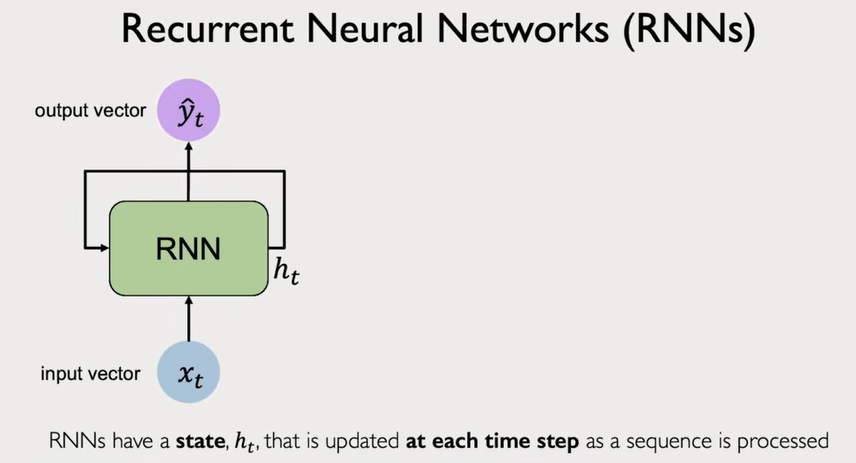


#### How RNNs work
Now imagine we are trying to predict the stock prices of Kengen from historical prices. The naive way of doing this would look something like this below. Where you are predicting tomorrow's price only from yesterday's value.

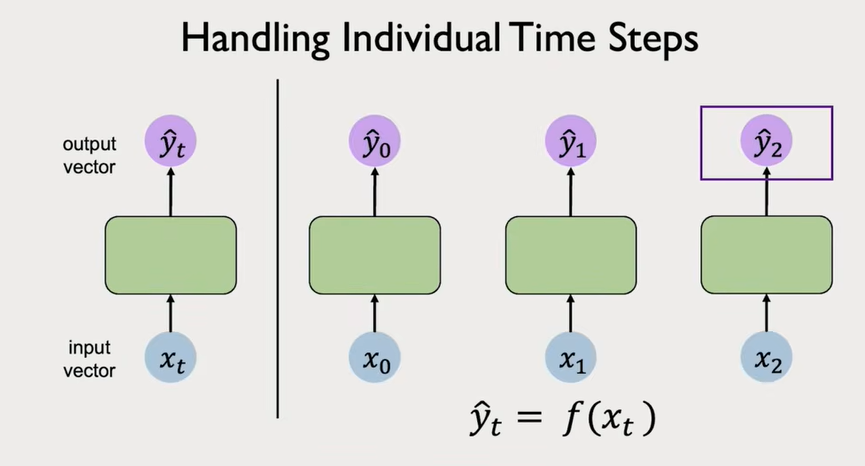

Unfortunately, this does not capture the temporal dependence usually seen with stock price data. How then do we relate these individual timesteps with each other? RNNs do this by introducing a special variable called the hidden state. What the hidden state does is, it links the internal computations from previous time steps, and allows the learned information from these computations to be passed along all timesteps in the network.


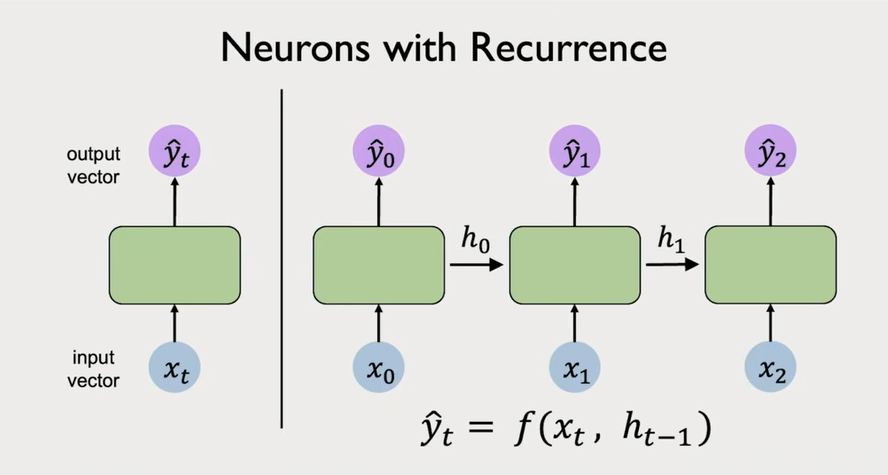

The RNN in short, goes through a recursive process where it takes the current input (x), looks at its previous hidden state (memory), calculates a weighted sum of the hidden state and input and applies an activation function to it (in our case I have used tanh, it can also be ReLU), produces a new hidden state (aka updates the memory at that time step)....

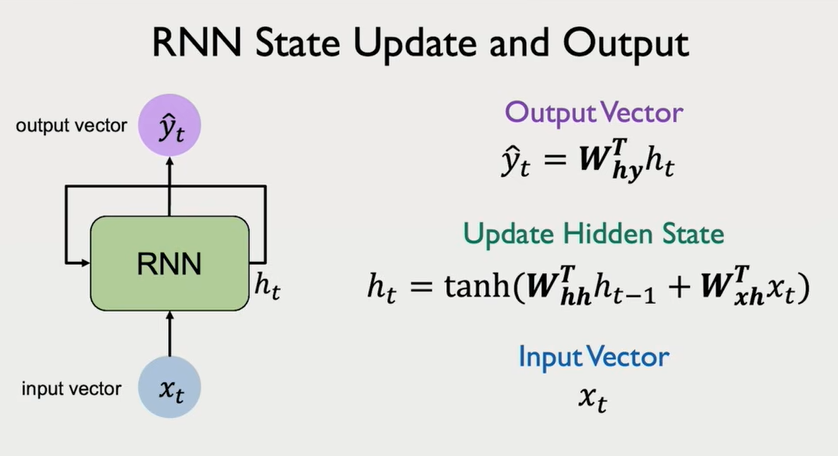


#### How RNNs learn: Backpropagation through time (BPTT)
BPTT works by extending the principle of regular backpropagation to handle sequential data. The key challenge is that in an RNN, the same network weights are reused at every time step, and each step's output depends on all previous steps through the hidden state. To train the network, we first perform a forward pass, processing the entire input sequence step by step while storing all the hidden states along the way. Once we reach the end and calculate the prediction error ( loss function), we then perform a backward pass that flows the error gradients backward through time—starting from the final step and moving back to the beginning. 

In short, we are trying to find the gradient of the loss function with respect to each weight at every time step (similar to traditional back propagation, but here the weights are the same across the time steps). These gradients accumulate as they flow backward through the unrolled network, and because the same weights are used at every time step, we sum up all the gradients across all time steps before making a single weight update.


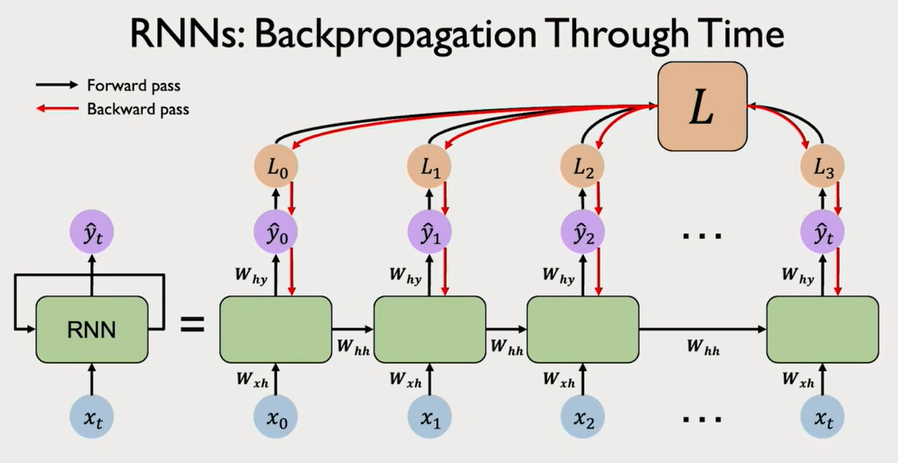


Let me try and make one thing clear, if you are understood the basic intuition of RNN, a question that you may have at this juncture is....if the same weights are passed on across each time step, why do we need backpropagation? Why not just calculate the loss with respect to the weight once? Let me try and use an example here so the point lands more clearly...

Understand that even though the weights are the same, the context in which they're applied is different at each time step, and those different contexts create different contributions to the final error.
Consider this example of predicting the next word in "The cat sat on the ___":

- At time step 1, the weights process "The" with an empty initial hidden state
- At time step 2, the same weights process "cat" but now with a hidden state that contains information about "The"
- At time step 3, the same weights process "sat" with a hidden state containing information about "The cat"
- At time step 4, the same weights process "on" with accumulated context from all previous words

The same weights are being used in different situations, with different inputs and different hidden states. So they contribute to the error in different ways at different times. When we perform BPTT, we're asking: "How did these weights contribute to the error across all the different times they were used?"

Perhaps at step 1, using weight W in a certain way was helpful for building context, but at step 3, using that same weight W contributed to a mistake. We need to know the net effect across all time steps. 

***So now BPTT will take the sum of the gradients of the loss with respect to weights at each time step and this total gradient is what will be used to update the weight , using our good old gradient descent formula***

```New weight = Old weight * (learning _rate X (total gradient))```

### Types of RNN

- One to one
- One to many
- Many to one
- Many to many

#### Limitations of RNNs
- Vanishing gradient problem

This occurs when gradients which help the model learn can shrink as they pass through many steps, especially during back propagation. This makes it hard for the model to learn long-term patterns since earlier information becomes almost irrelevant. So RNNs fail to capture relationships with long term dependencies

- Exploding gradient problem

This is the opposite of the vanishing gradient problem, in this case the gradients are so large, especially during back propagation. If the gradients are too large, it would mean that the new weights will be updated by a large margin causing the model to take huge 'jumps' and miss the local minima, causing very unpredictable and erratic outputs.

## Introduction to  Long Short-Term Memory (LSTM) 

LSTMs, introduced by Hochreiter and Schmidhuber in 1997, were specifically designed to solve the vanishing gradient problem and learn long-term dependencies. The key innovation is a ***memory cell*** with gating mechanisms that carefully control information flow.

Unlike in RNNs where there is only a hidden state to learn long-term dependencies, an LSTM has two types of state flowing through time:

- Cell State (C<sub>t</sub>): The long-term memory, a conveyor belt that runs through the entire sequence
- Hidden State (H<sub>t</sub>): The short-term memory, what gets passed to the next time step and used for outputs

At each time step, the LSTM model receives the current input, the previous hidden state (H<sub>t-1</sub>)  and the previous cell state (C<sub>t-1</sub>) and then through a series of transformations produces a hidden state and cell state to be passed to the next time step.

***The entire networks looks something a like this***

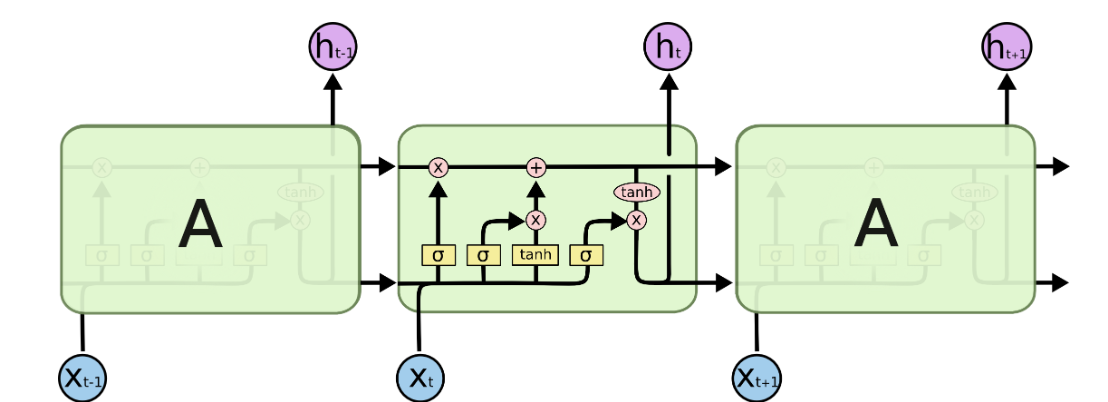





### LSTM Architecture

The key thing that makes LSTMs so powerful is the ***memory cell**, this is the horizontal line running through our diagram below. Think of the memory cell as conveyor belt that runs across the network and where information can be stored long-term and remains 'unchanged' (unless done so by the gates). This is the long-term memory of the network.

The information that is added, removed or updated into our long-term memory (the cell state), is controlled by 3 gates. Gates are a way to selectively let information into and out of the cell state, they are composed of activation functions (sigmoid/tanh) and elementwise multiplications of input values.

- **Forget gate**: Determines what information is removed from the cell state
- **Input gate**: Determines what information is added to the cell state
- **Output gate**: Controls what information is output from the cell state

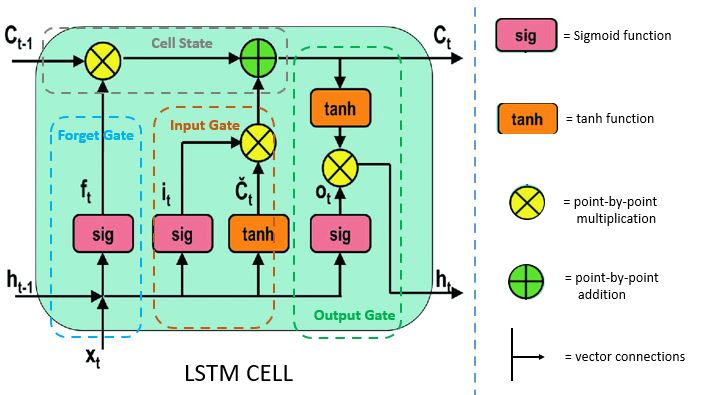

### Step-by-step walkthrough of LSTMs

##### 1. The Forget Gate


The first step of the LSTM is to decide what information is going to be 'forgotten' in our cell memory - what is being removed from the cell state. This decision is made by a sigmoid layer called the “forget gate layer.” It looks at (H<sub>t-1</sub>) and (x<sub>t</sub>) and outputs a number between 0 and 1. For each item in the cell state, (C<sub>t-1</sub>), if an item get 0 it is forgoten from the cell state and if 1 , it is kept.


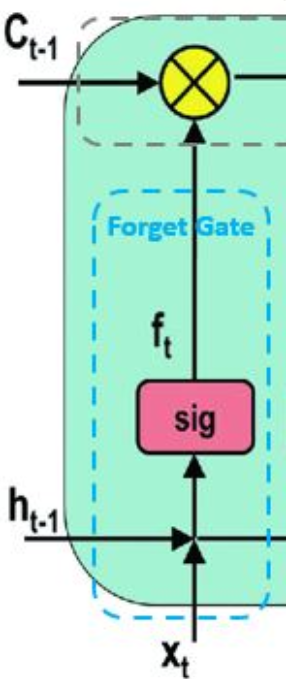



Let's say you have the sentence. *** Mercy is tall, but Dorice is taller ***

#### 2. The Input Gate

The input  gate decides which information will be added to the cell state. It does this in 2 stages, it uses the sigmoid function to decide which values are important and also tanh function to update the information. In short, the input gate's job is to quantify the importance of the new information carried by the input.

The input data (x<sub>t</sub>) at the current time step and the hidden state (H<sub>t-1</sub>) of the previous time step are in parallel fed through a sigmoid and tanh layer. The sigmoid layer decides how important the incoming information is, while the tanh layer kinda gives you the flavour /meaning of the incoming information given the context in the hidden layer. The output of both the sigmoid (important) and the tanh (flavor/meaning) are combined and sent to the cell state.

Let me use an example and not the math to make this make sense, imagine the sentence
"The tall man walked into the room..."

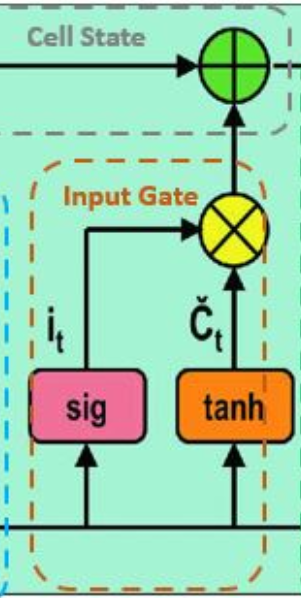


***Key takeaway: The input gate decides which words deserve long-term real estate in the network’s memory***

#### 3. The Output gate

The output gate is responsible for deciding what part of the current cell state should be sent as the hidden state (output) for this time step.First, the gate uses a sigmoid function to determine which information from the current cell state will be output. 

Just like the input gate, the output gate has 2 layers... the sigmoid layer and the tanh layer, and they both run in parallel.The model looks at the current input (x<sub>t</sub>)  and the previous hidden state (H<sub>t-1</sub>)  and runs them through a sigmoid function. Think of it this way, the sigmoid functions helps us decide which parts of the cell state are relevant given the current hidden state and input. What is useful NOW?. The tanh layer just prepares the memoery by squaishing it between -1 and 1, making it more stable.


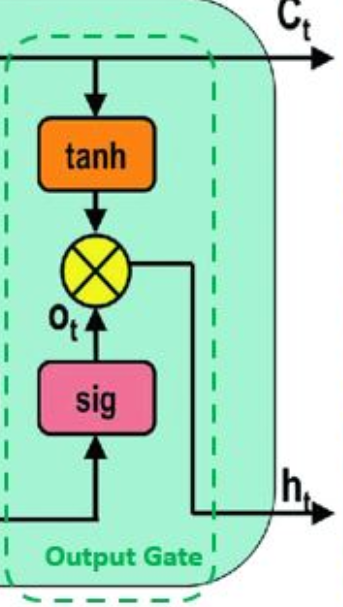


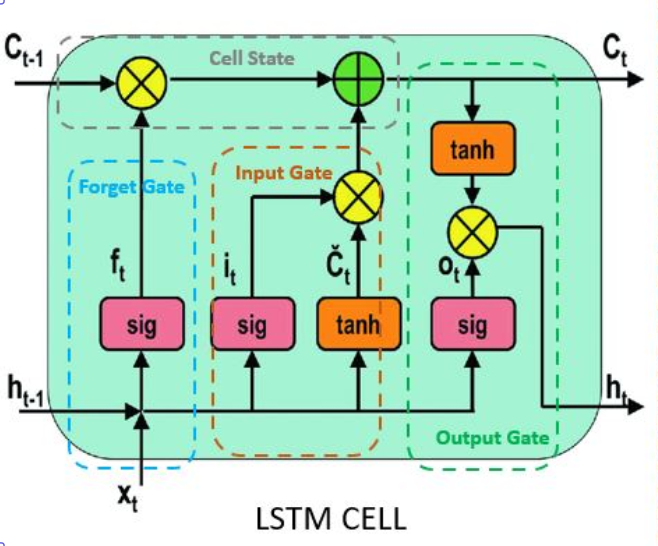